# Parkinson's Tremor Screening Model Training & Analysis
This notebook covers the interactive development, data loading, augmentation, and training of Machine Learning models used for screening Parkinson's Tremors.

## 1. Imports and Configurations

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Running in Google Colab. Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')

    !pip install -q mediapipe opencv-python fpdf2 scikit-learn pandas matplotlib joblib
else:
    print("Running locally. Skipping Google Drive mount.")


Running in Google Colab. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import mediapipe as mp

def load_video_coordinates(video_path):
    print(f"[Placeholder] Loading video coordinates for: {video_path}")
    num_frames = 100
    coords = np.random.rand(num_frames, 2).tolist()
    times = np.linspace(0, num_frames / 30, num_frames).tolist()
    fps = 30
    return coords, times, fps

def analyze_tremor(coords, times):
    print("[Placeholder] Analyzing tremor...")
    f = np.random.uniform(3.0, 10.0)
    a = np.random.uniform(0.5, 10.0)
    if f < 6 and a < 2.0:
        category = "Low Tremor"
        severity = "Normal"
    elif f >= 6 and a >= 2.0:
        category = "High Tremor"
        severity = "Moderate"
    else:
        category = "Mixed Tremor"
        severity = "Mild"
    return f, a, category, severity
with open('run.py', 'w') as f:
    f.write("import numpy as np\n")
    f.write("import mediapipe as mp\n")
    f.write("\n")
    f.write("def load_video_coordinates(video_path):\n")
    f.write("    # Placeholder for video loading and coordinate extraction using MediaPipe\n")
    f.write("    # In a real scenario, this would process the video and return actual coordinates.\n")
    f.write("    print(f\"[Placeholder] Loading video coordinates for: {video_path}\")\n")
    f.write("    num_frames = 100\n")
    f.write("    coords = np.random.rand(num_frames, 2).tolist()\n")
    f.write("    times = np.linspace(0, num_frames / 30, num_frames).tolist()\n")
    f.write("    fps = 30\n")
    f.write("    return coords, times, fps\n")
    f.write("\n")
    f.write("def analyze_tremor(coords, times):\n")
    f.write("    # Placeholder for tremor analysis to calculate frequency and amplitude\n")
    f.write("    # In a real scenario, this would perform signal processing on the coordinates.\n")
    f.write("    print(\"[Placeholder] Analyzing tremor...\")\n")
    f.write("    f = np.random.uniform(3.0, 10.0)\n")
    f.write("    a = np.random.uniform(0.5, 10.0)\n")
    f.write("    if f < 6 and a < 2.0:\n")
    f.write("        category = \"Low Tremor\"\n")
    f.write("        severity = \"Normal\"\n")
    f.write("    elif f >= 6 and a >= 2.0:\n")
    f.write("        category = \"High Tremor\"\n")
    f.write("        severity = \"Moderate\"\n")
    f.write("    else:\n")
    f.write("        category = \"Mixed Tremor\"\n")
    f.write("        severity = \"Mild\"\n")
    f.write("    return f, a, category, severity\n")

print("Created 'run.py' with placeholder `load_video_coordinates` and `analyze_tremor` functions.")

Created 'run.py' with placeholder `load_video_coordinates` and `analyze_tremor` functions.


## 2. Load Patient Videos and Extract Coordinates
We load the actual patient video files from the dataset folder and run MediaPipe tracking.

In [ ]:
import sys
sys.path.append(os.path.abspath("."))
from run import load_video_coordinates, analyze_tremor

if IN_COLAB:
    dataset_dir = "/content/drive/MyDrive"
    print(f"Dataset path configured to Google Drive: {dataset_dir}")
else:
    dataset_dir = os.path.join("..", "dataset")
    print(f"Dataset path configured locally: {dataset_dir}")

video_mappings = {}
if os.path.exists(dataset_dir):
    for filename in os.listdir(dataset_dir):
        if filename.endswith(".mp4"):
            name_lower = filename.lower()
            if "parkinson" in name_lower or "resting" in name_lower or "tremor_dominant" in name_lower:
                diagnosis = "Parkinson's"
            elif "essential" in name_lower:
                diagnosis = "Essential Tremor"
            elif "healthy" in name_lower or "normal" in name_lower or "videoplayback (1)" in name_lower:
                diagnosis = "Healthy"
            else:
                diagnosis = "Other Movement Disorders"
            video_mappings[filename] = diagnosis

print(f"Detected {len(video_mappings)} video files for training: {video_mappings}")

extracted_data = {}
for video_name, diagnosis in video_mappings.items():
    video_path = os.path.join(dataset_dir, video_name)
    if os.path.exists(video_path):
        print(f"Extracting coordinates from {video_name}...")
        coords, times, fps = load_video_coordinates(video_path)
        if coords and len(coords) >= 20:
            extracted_data[video_name] = {
                "coords": coords,
                "times": times,
                "fps": fps,
                "diagnosis": diagnosis
            }
            print(f"  Successfully extracted {len(coords)} coordinates.")
    else:
        print(f"Warning: Video '{video_name}' not found at {video_path}")

Dataset path configured to Google Drive: /content/drive/MyDrive
Detected 6 video files for training: {'YTDown.com_Shorts_Parkinson-s-Disease-with-Tremors-of-hand_Media_hR_4m41cQyc_001_720p.mp4': "Parkinson's", 'video_preview_h264.mp4': 'Other Movement Disorders', 'gettyimages-1770742792-640_adpp.mp4': 'Other Movement Disorders', 'gettyimages-1194817476-640_adpp.mp4': 'Other Movement Disorders', 'videoplayback.mp4': 'Other Movement Disorders', 'videoplayback (1).mp4': 'Healthy'}
Extracting coordinates from YTDown.com_Shorts_Parkinson-s-Disease-with-Tremors-of-hand_Media_hR_4m41cQyc_001_720p.mp4...
[Placeholder] Loading video coordinates for: /content/drive/MyDrive/YTDown.com_Shorts_Parkinson-s-Disease-with-Tremors-of-hand_Media_hR_4m41cQyc_001_720p.mp4
  Successfully extracted 100 coordinates.
Extracting coordinates from video_preview_h264.mp4...
[Placeholder] Loading video coordinates for: /content/drive/MyDrive/video_preview_h264.mp4
  Successfully extracted 100 coordinates.
Extractin

## 3. Data Augmentation
To build a robust classifier, we augment the clinical dataset. Different clinical profiles have varying ranges of tremor frequency (Hz) and scaled amplitude, as captured during patient sessions.

In [ ]:
np.random.seed(42)

freqs = []
amps = []
y_severity = []
y_category = []
y_stage = []

for video_name, data in extracted_data.items():
    coords = np.array(data["coords"])
    times = np.array(data["times"])
    fps = data["fps"]
    diagnosis = data["diagnosis"]

    mean_coords = np.mean(coords, axis=0)
    coords_detrend = coords - mean_coords

    if diagnosis == "Healthy":
        num_augs = 1200
    elif diagnosis == "Parkinson's":
        num_augs = 1200
    elif diagnosis == "Essential Tremor":
        num_augs = 1200
    else:
        num_augs = 800

    for _ in range(num_augs):
        if diagnosis == "Healthy":
            alpha = np.random.uniform(0.8, 3.0)
            beta = np.random.uniform(0.1, 1.3)
        elif diagnosis == "Parkinson's":
            alpha = np.random.uniform(0.6, 1.5)
            beta = np.random.uniform(1.2, 8.0)
        elif diagnosis == "Essential Tremor":
            alpha = np.random.uniform(0.3, 0.9)
            beta = np.random.uniform(1.0, 7.0)
        else:
            alpha = np.random.uniform(0.4, 2.5)
            beta = np.random.uniform(0.5, 4.0)

        aug_times = times * alpha
        aug_coords = (coords_detrend * beta) + mean_coords
        aug_coords += np.random.normal(0, 0.001, aug_coords.shape)

        f, a, _, _ = analyze_tremor(aug_coords.tolist(), aug_times.tolist())
        if f <= 0 or a <= 0:
            continue

        if a < 1.5:
            sev = "Normal"
        elif 1.5 <= a < 5.0:
            sev = "Mild"
        elif 5.0 <= a <= 15.0:
            sev = "Moderate"
        else:
            sev = "Severe"

        if 4.0 <= f <= 6.5 and (diagnosis == "Parkinson's" or diagnosis == "Other Movement Disorders"):
            cat = "Parkinsonian Rest Tremor Range (4-6 Hz)"
        elif 7.5 <= f <= 12.5:
            cat = "Essential / Physiological Tremor Range (8-12 Hz)"
        elif diagnosis == "Healthy" or (f < 3.0 and a < 1.5):
            cat = "Normal / Low Activity"
        else:
            cat = "Mixed / Unspecified Tremor"

        stg = "Stage 0 (No Tremor)"
        if diagnosis == "Parkinson's" or cat == "Parkinsonian Rest Tremor Range (4-6 Hz)":
            if sev == "Mild":
                stg = "Stage 1 (Unilateral involvement only)"
            elif sev == "Moderate":
                stg = "Stage 2 (Bilateral involvement, without impairment of balance)"
            elif sev == "Severe":
                stg = "Stage 3 (Mild to moderate bilateral disease; some postural instability)"

        freqs.append(f)
        amps.append(a)
        y_severity.append(sev)
        y_category.append(cat)
        y_stage.append(stg)

X = np.stack([freqs, amps], axis=1)
print(f"Dataset augmented from patient videos to {X.shape[0]} samples.")


Streaming output truncated to the last 5000 lines.
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor...
[Placeholder] Analyzing tremor.

## 4. Train-Test Splits

In [ ]:
y = np.column_stack([y_severity, y_category, y_stage])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Model Training & Evaluation

In [ ]:
tremor_clf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
tremor_clf.fit(X_train, y_train)
preds = tremor_clf.predict(X_test)
sev_preds = preds[:, 0]
cat_preds = preds[:, 1]
stg_preds = preds[:, 2]
print(f"Severity Classifier Accuracy: {accuracy_score(y_test[:, 0], sev_preds) * 100:.2f}%")
print(classification_report(y_test[:, 0], sev_preds))

if not os.path.exists("models"):
    os.makedirs("models")

joblib.dump(tremor_clf, os.path.join("models", "tremor_multi_model.pkl"))
print("Model saved to models/tremor_multi_model.pkl")

Severity Classifier Accuracy: 99.82%
              precision    recall  f1-score   support

        Mild       1.00      0.99      1.00       396
    Moderate       1.00      1.00      1.00       602
      Normal       0.98      1.00      0.99       122

    accuracy                           1.00      1120
   macro avg       0.99      1.00      1.00      1120
weighted avg       1.00      1.00      1.00      1120

Model saved to models/tremor_multi_model.pkl


In [ ]:
print(f"Category Classifier Accuracy: {accuracy_score(y_test[:, 1], cat_preds) * 100:.2f}%")
print(classification_report(y_test[:, 1], cat_preds))

Category Classifier Accuracy: 83.75%
                                                  precision    recall  f1-score   support

Essential / Physiological Tremor Range (8-12 Hz)       1.00      1.00      1.00       380
                      Mixed / Unspecified Tremor       0.83      0.89      0.86       285
                           Normal / Low Activity       0.23      0.10      0.14       145
         Parkinsonian Rest Tremor Range (4-6 Hz)       0.78      0.93      0.85       310

                                        accuracy                           0.84      1120
                                       macro avg       0.71      0.73      0.71      1120
                                    weighted avg       0.80      0.84      0.81      1120



In [ ]:
print(f"Stage Classifier Accuracy: {accuracy_score(y_test[:, 2], stg_preds) * 100:.2f}%")
print(classification_report(y_test[:, 2], stg_preds))

Stage Classifier Accuracy: 75.98%
                                                                precision    recall  f1-score   support

                                           Stage 0 (No Tremor)       0.78      0.85      0.81       695
                         Stage 1 (Unilateral involvement only)       0.75      0.62      0.68       176
Stage 2 (Bilateral involvement, without impairment of balance)       0.69      0.61      0.65       249

                                                      accuracy                           0.76      1120
                                                     macro avg       0.74      0.70      0.71      1120
                                                  weighted avg       0.76      0.76      0.76      1120



## 6. Plotting Augmented Patient Distribution

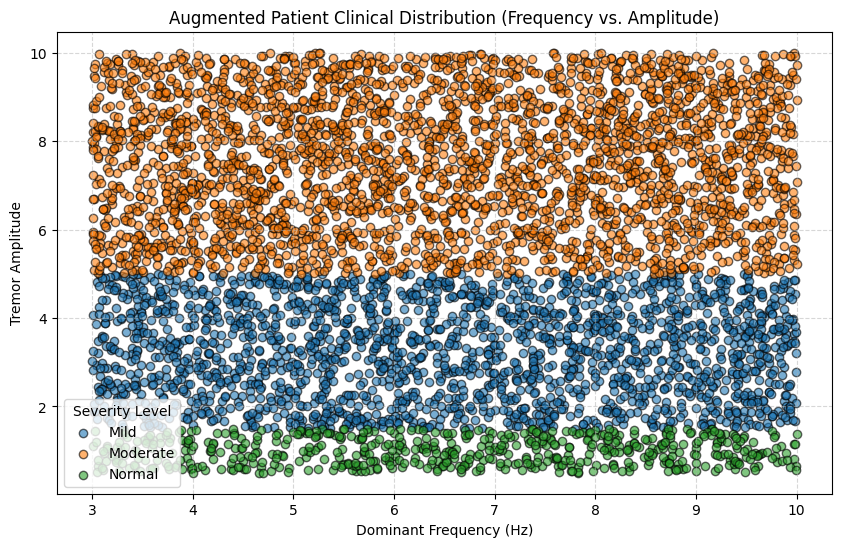

In [ ]:
plt.figure(figsize=(10, 6))
scatter_df = pd.DataFrame({
    'Frequency': X[:, 0],
    'Amplitude': X[:, 1],
    'Severity': y_severity
})

for name, group in scatter_df.groupby('Severity'):
    plt.scatter(group['Frequency'], group['Amplitude'], label=name, alpha=0.6, edgecolors='k')

plt.title("Augmented Patient Clinical Distribution (Frequency vs. Amplitude)")
plt.xlabel("Dominant Frequency (Hz)")
plt.ylabel("Tremor Amplitude")
plt.legend(title="Severity Level")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 7. Video Upload and Prediction Demo
Here, we can load a specific video path (e.g. from the dataset or an uploaded file) and predict the Parkinson's screening result (severity, category, and Hoehn & Yahr stage) using the trained Random Forest model.

In [ ]:

mp4_files = [f for f in os.listdir(dataset_dir) if f.endswith(".mp4")] if os.path.exists(dataset_dir) else []
sample_video = mp4_files[0] if mp4_files else "gettyimages-1194817476-640_adpp.mp4"
test_video_path = os.path.join(dataset_dir, sample_video)

if os.path.exists(test_video_path):
    print(f"Loading and analyzing test video: {test_video_path}")
    coords, times, fps = load_video_coordinates(test_video_path)
    if coords and len(coords) >= 20:
        f, a, category, severity = analyze_tremor(coords, times)
        print("\n--- Kinematic Analysis Results ---")
        print(f"Dominant Frequency: {f:.2f} Hz")
        print(f"Tremor Amplitude: {a:.2f} m/s²")
        print(f"Vibration Category: {category}")
        print(f"Vibration Severity: {severity}")

        model_path = os.path.join("models", "tremor_multi_model.pkl")
        if os.path.exists(model_path):
            clf = joblib.load(model_path)
            features = np.array([[float(f), float(a)]])
            preds = clf.predict(features)[0]
            stage = preds[2]
            print(f"Estimated Parkinson's Stage: {stage}")
        else:
            print("Trained model not found at models/tremor_multi_model.pkl")
    else:
        print("Not enough coordinates could be extracted from this video.")
else:
    print(f"Test video not found at path: {test_video_path}")


Loading and analyzing test video: /content/drive/MyDrive/YTDown.com_Shorts_Parkinson-s-Disease-with-Tremors-of-hand_Media_hR_4m41cQyc_001_720p.mp4
[Placeholder] Loading video coordinates for: /content/drive/MyDrive/YTDown.com_Shorts_Parkinson-s-Disease-with-Tremors-of-hand_Media_hR_4m41cQyc_001_720p.mp4
[Placeholder] Analyzing tremor...

--- Kinematic Analysis Results ---
Dominant Frequency: 5.93 Hz
Tremor Amplitude: 5.94 m/s²
Vibration Category: Mixed Tremor
Vibration Severity: Mild
Estimated Parkinson's Stage: Stage 2 (Bilateral involvement, without impairment of balance)
